# 1. Imports & Setup

In [1]:
# Data manipulation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Model Training Utilities
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# NLP libraries
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter

# 2. Load Dataset

In [2]:
fake = pd.read_csv("/kaggle/input/fake-and-real-news-dataset/Fake.csv")
real = pd.read_csv("/kaggle/input/fake-and-real-news-dataset/True.csv")

fake["label"] = 0  # fake
real["label"] = 1  # real

# Combine real and fake into one dataset
df = pd.concat([real, fake], ignore_index=True)
df = df.sample(frac=1).reset_index(drop=True)

df.head()

,title,text,subject,date,label
0,Confused Old Man Shows Up At The Golf Course ...,A tired 70-year-old man keeps forgetting to sh...,News,"April 2, 2017",0
1,EP #17: Patrick Henningsen LIVE – ‘Parallax Po...,Join Patrick every Wednesday at Independent Ta...,Middle-east,"March 16, 2017",0
2,FAST AND FURIOUS Hearing Rips Obama and Holder...,Members of a congressional committee ripped Ob...,politics,"Jun 9, 2017",0
3,"Top U.S. diplomat, security chief to visit Mex...",WASHINGTON (Reuters) - Secretary of State Rex ...,politicsNews,"February 21, 2017",1
4,Ecuador president removed as head of ruling pa...,QUITO (Reuters) - Ecuador s ruling Country All...,worldnews,"November 1, 2017",1


# 3. Text Preprocessing

In [3]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

stop_words = set(stopwords.words("english"))

def clean_text(text):
    # Remove Twitter handles starting with '@'
    text = re.sub(r'@\w+', '', text)
    
    # Remove non-alphanumeric characters and extra whitespace
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Convert multiple whitespace characters to a single space
    text = re.sub(r'\s+', ' ', text)
    
    # Convert the text to lowercase
    text = text.lower()
   # Tokenize
    tokens = word_tokenize(text)

    # Remove stop words
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# 4. Prepare Vocabulary

In [4]:
all_tokens = []
for text in df["text"]:
    all_tokens.extend(clean_text(text))

vocab_counts = Counter(all_tokens)
vocab = [word for word, count in vocab_counts.items() if count >= 5]  # filter rare
vocab = ["<PAD>", "<UNK>"] + vocab

word2idx = {w: idx for idx, w in enumerate(vocab)}
PAD_IDX = word2idx["<PAD>"]
UNK_IDX = word2idx["<UNK>"]

# 5. Sequence Encoding + Padding

In [5]:
MAX_LEN = 100

def encode_and_pad(tokens):
    ids = [word2idx.get(w, UNK_IDX) for w in tokens]
    if len(ids) < MAX_LEN:
        ids = ids + [PAD_IDX] * (MAX_LEN - len(ids))
    else:
        ids = ids[:MAX_LEN]
    return ids

df["input_ids"] = df["text"].apply(lambda x: encode_and_pad(clean_text(x)))

# 6. Train–Validation Split

In [6]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["label"])

# 7. PyTorch Dataset + DataLoader

In [7]:
class TextDataset(Dataset):
    def __init__(self, dataframe):
        self.data = dataframe

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        return torch.tensor(row["input_ids"]), torch.tensor(row["label"])

train_loader = DataLoader(TextDataset(train_df), batch_size=32, shuffle=True)
val_loader = DataLoader(TextDataset(val_df), batch_size=32)

# 8. LSTM Model Definition

In [8]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, n_layers, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, num_layers=n_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        output, (hidden, cell) = self.lstm(x)
        x = self.fc(hidden[-1])
        return self.sigmoid(x)

# 9. Model Initialization

In [9]:
VOCAB_SIZE = len(vocab)
EMBED_DIM = 100
HIDDEN_DIM = 128
N_LAYERS = 2
OUTPUT_DIM = 1

model = LSTMClassifier(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, N_LAYERS, OUTPUT_DIM)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 10. Training + Validation Loop

In [10]:
EPOCHS = 10

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

train_f1_scores = []
val_f1_scores = []

for epoch in range(EPOCHS):
    
    # -------- Training --------
    model.train()
    total_train_loss = 0
    y_train_true = []
    y_train_pred = []
    
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs).squeeze()
        loss = criterion(outputs, labels.float())
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        
        preds = (outputs >= 0.5).int()
        y_train_true.extend(labels.tolist())
        y_train_pred.extend(preds.tolist())
    
    train_loss = total_train_loss / len(train_loader)
    train_acc = accuracy_score(y_train_true, y_train_pred)
    train_f1 = f1_score(y_train_true, y_train_pred)
    
    # -------- Validation --------
    model.eval()
    total_val_loss = 0
    y_val_true = []
    y_val_pred = []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels.float())
            total_val_loss += loss.item()
            
            preds = (outputs >= 0.5).int()
            y_val_true.extend(labels.tolist())
            y_val_pred.extend(preds.tolist())
    
    val_loss = total_val_loss / len(val_loader)
    val_acc = accuracy_score(y_val_true, y_val_pred)
    val_f1 = f1_score(y_val_true, y_val_pred)
    
    # -------- Store Metrics --------
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    train_f1_scores.append(train_f1)
    val_f1_scores.append(val_f1)
    
    # -------- Print Results --------
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    print(f"Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f}")
    print("-" * 50)

Epoch 1/10
Train Loss: 0.3450 | Val Loss: 0.2966
Train Acc: 0.8581 | Val Acc: 0.9001
Train F1: 0.8567 | Val F1: 0.9013
--------------------------------------------------
Epoch 2/10
Train Loss: 0.1590 | Val Loss: 0.0195
Train Acc: 0.9344 | Val Acc: 0.9970
Train F1: 0.9337 | Val F1: 0.9968
--------------------------------------------------
Epoch 3/10
Train Loss: 0.0168 | Val Loss: 0.0095
Train Acc: 0.9967 | Val Acc: 0.9982
Train F1: 0.9965 | Val F1: 0.9981
--------------------------------------------------
Epoch 4/10
Train Loss: 0.0087 | Val Loss: 0.0075
Train Acc: 0.9984 | Val Acc: 0.9987
Train F1: 0.9984 | Val F1: 0.9986
--------------------------------------------------
Epoch 5/10
Train Loss: 0.0071 | Val Loss: 0.0080
Train Acc: 0.9985 | Val Acc: 0.9987
Train F1: 0.9984 | Val F1: 0.9986
--------------------------------------------------
Epoch 6/10
Train Loss: 0.0051 | Val Loss: 0.0074
Train Acc: 0.9989 | Val Acc: 0.9990
Train F1: 0.9989 | Val F1: 0.9989
-------------------------------

# 11. Confusion Matrix & Classification Report


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



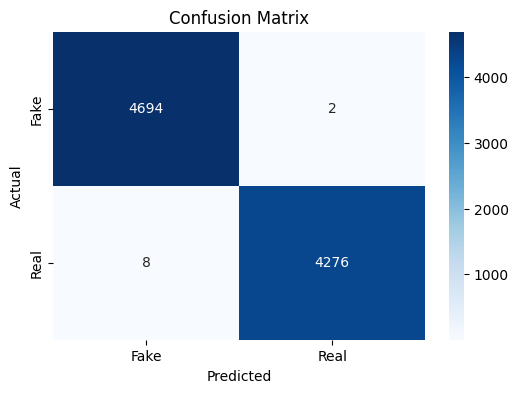

In [11]:
# Classification Report
print("\nClassification Report:\n", classification_report(y_val_true, y_val_pred))

# Confusion Matrix
cm = confusion_matrix(y_val_true, y_val_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 12. Loss and Accuracy over Epochs

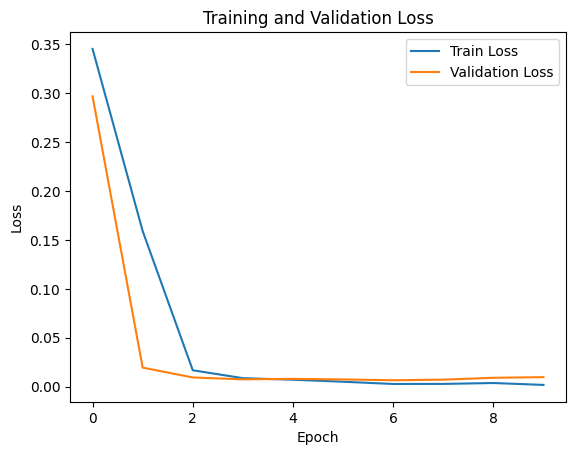

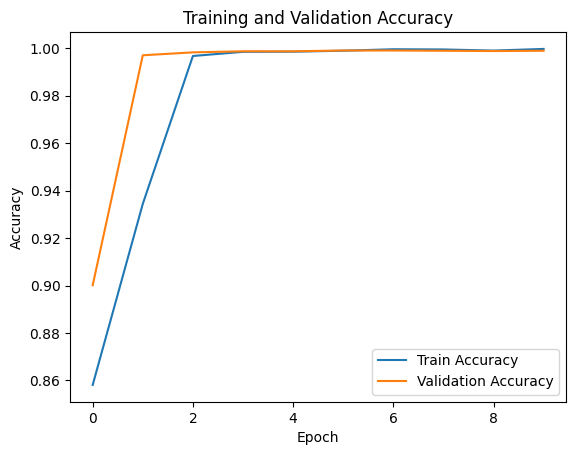

In [12]:
# Training & Validation Loss
plt.figure()
plt.plot(train_losses)
plt.plot(val_losses)
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train Loss", "Validation Loss"])
plt.show()

# Training & Validation Accuracy
plt.figure()
plt.plot(train_accuracies)
plt.plot(val_accuracies)
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train Accuracy", "Validation Accuracy"])
plt.show()

# 13. Save Model

In [13]:
import torch

MODEL_PATH = "lstm_fake_news_model.pth"

# Save only model weights (recommended)
torch.save(model.state_dict(), MODEL_PATH)

print(f"Model saved successfully at {MODEL_PATH}")

Model saved successfully at lstm_fake_news_model.pth
